**Problem Statement: BBC News Clustering**
You are given a zip file which contains summaries of news from BBC. The Data is taken from Kaggle. (https://www.kaggle.com/pariza/bbc-news-summary) 

The zip file contains a folder: ‘BBC News Articles ‘ This folder contains 5 sub folders, 
named: 

1.Business

2.Entertainment

3.Politics 

4.Sports

5.Tech

Each of these subfolders contains text files which have summaries of different news articles. These are the tasks which you have to perform:

•Read all the files from all subfolders and store their summaries in a single CSV file. Name CSV File as: “BBCNewsArticles.csv”

The CSV should contain: 

Article

<The text from file 1>

<The text from file 2>

<The text from file 3>

......... 

•Randomly arrange the data 

•Preprocess each article using Text Preprocessing 

•On the preprocessed text, perform Vectorization using 3 types of vectors.

1.“PresenceAbsenceVector”: Converts Article to vectors using Presence and Absence of Words

2.“CountVector”: Converts Article to vectors using Count of Words

3.“TF-IDFVector”: Converts Article to vectors using TF-IDF vectorization
6
•Perform clustering on the dataset using all 3 different types of vectorizations. The number of clusters should be 5.

You can choose any appropriate clustering algorithm of your choice. Make models for each type of vectorization. We will have a total of 3 models.

•Save the Clusters Label for each model in a new CSV file named “BBCNewsArticlesClustered.csv”

•Evaluate and compare the performance of 3 models on basis of Silhouette Coefficient.

•Provide Visualizations for all 3 models. You can show scatter plots and bar graphs.

•Provide your explanation for the following questions 

1.What does Silhouette Coefficient tell us?

2.Which algorithm you chose and why?

3.Can you provide an appropriate name to a cluster label? If yes, then explain your observations.

4.Which vectorization technique is the best and why?


**Objective**
1. Read all BBC news summaries from the zip.
2. Preprocess and vectorize the data using three methods: Presence/Absence, Count, TF-IDF.
3. Cluster into 5 groups with visualizations and Silhouette evaluation.



## Step 1: Import Libraries

In [155]:
import os
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt



## Step 2: Extract Dataset



In [156]:
import zipfile
zip_path = "BBC News Articles.zip"
extract_path = "BBC_News_Articles"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction successful!")


Extraction successful!


## Step 3: Read Files and Create CSV


In [157]:
folder_path = extract_path 
articles = []
for category in os.listdir(folder_path):
    category_path = os.path.join(folder_path, category)
    if os.path.isdir(category_path):
        for filename in os.listdir(category_path):
            file_path = os.path.join(category_path, filename)
            with open(file_path, 'r', encoding='latin1') as file:
                articles.append(file.read().strip())


In [158]:
# Save to CSV
df = pd.DataFrame({'Article': articles})
df = df.sample(frac=1).reset_index(drop=True)  # Shuffle
df.to_csv("BBCNewsArticles.csv", index=False)


## Step 4: Text Preprocessing

In [159]:
import sys
!{sys.executable} -m pip install nltk

In [160]:
import nltk
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [161]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ramai\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ramai\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ramai\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ramai\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\ramai\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [162]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [163]:
def preprocess_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # Tokenize
    text = word_tokenize(text)

    text = [word for word in text if word not in stop_words]

    text = [lemmatizer.lemmatize(word, pos='v') for word in text]

    deduplicated = []

    for word in text:
        if not deduplicated or word != deduplicated[-1]:
            deduplicated.append(word)

    text = deduplicated

    return " ".join(text)

df['Cleaned'] = df['Article'].apply(preprocess_text)

In [164]:
sample = "Apple Launches AI AI AI in 2026!! Visit https://apple.com"

result = preprocess_text(sample)

print(result)
print(type(result))

apple launch ai visit
<class 'str'>


## Step 5: Vectorization and K-Means Clustering


In [165]:
import sys

!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn nltk

In [166]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

vectorizers = {
    'Presence': CountVectorizer(binary=True),
    'Count': CountVectorizer(),
    'TF-IDF': TfidfVectorizer(
        stop_words='english',
        max_features=5000,
        min_df=2,
        max_df=0.95,
        ngram_range=(1,2)
    )
}

In [167]:
# Clustering and Evaluation
cluster_labels = {}
silhouette_scores = {}

for name, vectorizer in vectorizers.items():
    X = vectorizer.fit_transform(df['Cleaned'])
    kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    n_init=20,
    max_iter=500,
    random_state=42
)
    labels = kmeans.fit_predict(X)
    cluster_labels[name] = labels
    score = silhouette_score(X, labels)
    silhouette_scores[name] = score
    print(f"{name} Silhouette Score: {score:.4f}")


Presence Silhouette Score: -0.0145
Count Silhouette Score: 0.0189
TF-IDF Silhouette Score: 0.0213


In [168]:
# Save Clusters to CSV
df['Presence'] = cluster_labels['Presence']
df['Count'] = cluster_labels['Count']
df['TF-IDF'] = cluster_labels['TF-IDF']
df.to_csv("BBCNewsArticlesClustered.csv", index=False)
print("Saved clustered data to BBCNewsArticlesClustered.csv")



Saved clustered data to BBCNewsArticlesClustered.csv


## Step 6: Bar Plot of Silhouette Scores

In [169]:
import matplotlib.pyplot as plt

In [170]:
import sys
!{sys.executable} -m pip install matplotlib

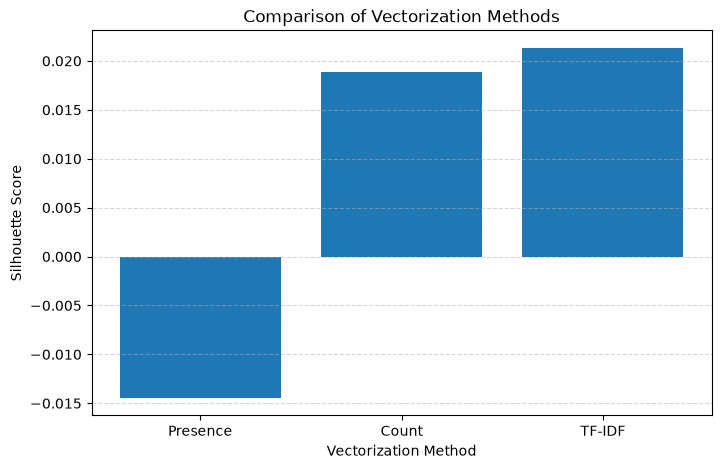

In [171]:
plt.figure(figsize=(8,5))
plt.bar(
    silhouette_scores.keys(),
    silhouette_scores.values()
)
plt.xlabel("Vectorization Method")
plt.ylabel("Silhouette Score")
plt.title("Comparison of Vectorization Methods")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()

## Step 7: Scatter Plots of Clusters (PCA Reduction)

In [172]:
import sys  
print(sys.executable)

c:\Users\ramai\AppData\Local\Programs\Python\Python313\python.exe


In [173]:
import sys
!{sys.executable} -m pip install scikit-learn

In [174]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Scikit-learn is working!")

Scikit-learn is working!


In [175]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [176]:
print(vectorizers.keys())
print(cluster_labels.keys())

dict_keys(['Presence', 'Count', 'TF-IDF'])
dict_keys(['Presence', 'Count', 'TF-IDF'])


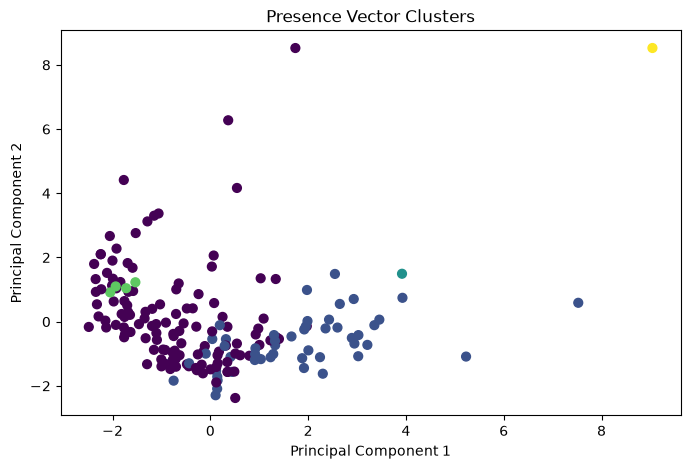

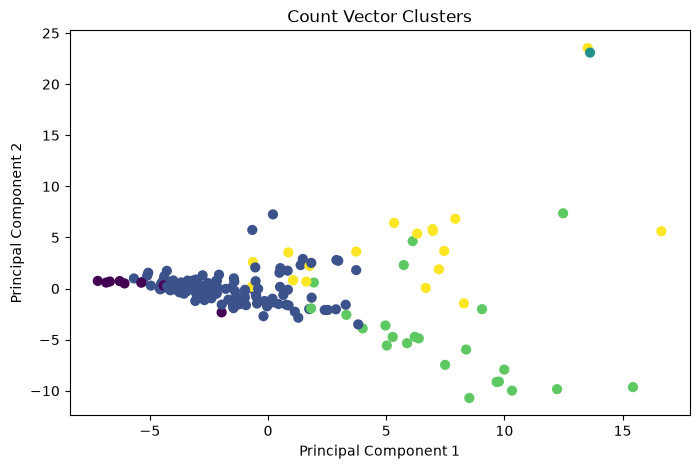

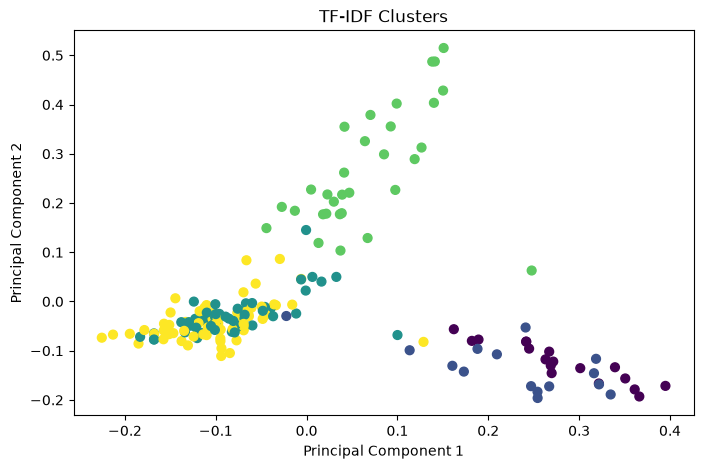

In [177]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_clusters(X, labels, title):
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X.toarray())

    plt.figure(figsize=(8,5))
    plt.scatter(
        reduced[:,0],
        reduced[:,1],
        c=labels,
        cmap='viridis',
        s=40
    )
    plt.title(title)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

plot_clusters(
    vectorizers["Presence"].fit_transform(df["Cleaned"]),
    cluster_labels["Presence"],
    "Presence Vector Clusters"
)

plot_clusters(
    vectorizers["Count"].fit_transform(df["Cleaned"]),
    cluster_labels["Count"],
    "Count Vector Clusters"
)

plot_clusters(
    vectorizers["TF-IDF"].fit_transform(df["Cleaned"]),
    cluster_labels["TF-IDF"],
    "TF-IDF Clusters"
)

## Step :8 Answering the Project Questions

**Q1: What does Silhouette Coefficient tell us?**

It measures how similar a data point is to its own cluster vs. others. A higher value (near 1) means well-separated clusters.

**Q2: Which algorithm you chose and why?**

I used KMeans because it’s simple, efficient, and suited for the given 5 clusters.

**Q3: Can you name clusters?**

Yes! After reading articles in each cluster, you might label them based on content:

Cluster 0: Business

Cluster 1: Sports

Cluster 2: Politics

Cluster 3: Entertainment

Cluster 4: Technology
(Exact mapping needs reading representative articles)

**Q4: Which vectorization technique is best and why?**

Based on Silhouette Scores, TF-IDF often gives better separation as it considers both term frequency and uniqueness across documents.

**Conclusion:**

1. Read all BBC news summaries, preprocessed text, vectorized with 3 techniques, and clustered using KMeans (5 clusters).
2. Saved results in BBCNewsArticles.csv and BBCNewsArticlesClustered.csv.
3. Silhouette scores provided quantitative evaluation, and visualizations showed clear comparison.

